# 🏆 Scoring Multicriterio

## ¿Por qué un scoring y no simplemente el ranking de ganancia?

El ranking de ganancia mensual responde solo una pregunta. Pero un conductor
real tiene múltiples criterios al momento de comprar un auto:

- ¿Cuánto capital tengo disponible?
- ¿Priorizo ganar más o perder menos en el peor escenario?
- ¿Me importa la resiliencia ante una devaluación?
- ¿Qué tan rápido quiero recuperar la inversión?

El **scoring multicriterio** construye un puntaje 0-100 para cada auto
combinando todas estas dimensiones con pesos configurables según el perfil
del conductor. Permite comparar autos que no son directamente comparables
con un solo número.

## Dimensiones del scoring

| Dimensión | Variable base | ¿Qué mide? |
|---|---|---|
| Rentabilidad | Ganancia P50 Montecarlo | Ganancia típica mensual |
| Resiliencia | Ganancia P10 Montecarlo | Peor escenario probable |
| Accesibilidad | Precio de compra | Qué tan fácil es entrar |
| Payback | Meses para recuperar inversión | Velocidad de retorno |
| Estabilidad | Desvío estándar Montecarlo | Predictibilidad de ingresos |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.append("..")

# Cargar resultados de Montecarlo
# (necesitamos correr la simulación de nuevo o cargar los resultados)
from src.modelo import PARAMETROS
import requests
from bs4 import BeautifulSoup

def get_tipo_cambio():
    url = "https://dolarhoy.com/"
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.text, "html.parser")
    valores = soup.find_all("div", class_="val")
    venta_blue = valores[5].text.strip().replace("$","").replace(".","").replace(",",".")
    return float(venta_blue)

TIPO_CAMBIO = get_tipo_cambio()
df = pd.read_csv("../data/processed/precios_autos_procesado.csv")
precio_mediano = df.groupby("modelo")["precio_usd"].median()

np.random.seed(42)
N = 10_000
p = PARAMETROS

consumo_por_modelo = {
    "Toyota Etios":     8.5, "Toyota Corolla":   9.0,
    "Toyota Yaris":     8.0, "Chevrolet Prisma":  8.5,
    "Renault Logan":    8.0, "Nissan Versa":      9.0,
    "VW Virtus":        8.5, "VW Voyage":         9.5,
    "VW Gol":           9.0, "Ford Ka":           8.0,
    "Ford Fiesta":      9.0, "Fiat Siena":        9.5,
    "Peugeot 208":      7.5,
}

tiene_gnc = {
    "Toyota Etios": False, "Toyota Corolla": False, "Toyota Yaris": False,
    "Chevrolet Prisma": True, "Renault Logan": True, "Nissan Versa": False,
    "VW Virtus": False, "VW Voyage": True, "VW Gol": True,
    "Ford Ka": False, "Ford Fiesta": False, "Fiat Siena": True, "Peugeot 208": False,
}

def simular(precio_usd, consumo, gnc, n=N):
    nafta  = np.random.normal(p["precio_nafta_ars_litro"], p["precio_nafta_ars_litro"]*0.15, n)
    gncp   = np.random.normal(p["precio_gnc_ars_m3"], p["precio_gnc_ars_m3"]*0.15, n)
    km_dia = np.abs(np.random.normal(p["km_diarios"], 20, n))
    tc     = np.abs(np.random.normal(TIPO_CAMBIO, 150, n))
    ing    = np.random.triangular(1_400_000, 2_000_000, 2_800_000, n)

    km_mes = km_dia * p["dias_laborales_mes"]
    costo_comb = (km_mes/100)*10*gncp if gnc else (km_mes/100)*consumo*nafta
    amort = (precio_usd * tc / p["vida_util_km"]) * km_mes
    ing_neto = ing * (1 - p["comision_cabify"])
    ganancia_ars = ing_neto - costo_comb - amort - p["seguro_mensual_ars"] - p["patente_anual_ars"]/12
    return ganancia_ars / tc

resultados_mc = {}
for modelo in consumo_por_modelo:
    resultados_mc[modelo] = simular(precio_mediano[modelo], consumo_por_modelo[modelo], tiene_gnc[modelo])

print("Simulación lista ✅")

Simulación lista ✅


### Construcción del scoring

Cada dimensión se normaliza al rango 0-100 usando **min-max scaling**:

score = (valor - min) / (max - min) * 100

Esto hace que el peor auto en cada dimensión reciba 0 y el mejor reciba 100,
permitiendo comparar dimensiones que tienen unidades distintas (USD, meses, etc.).

Los pesos de cada dimensión suman 1.0 y son configurables según el perfil
del conductor.

In [2]:
def minmax(serie):
    return (serie - serie.min()) / (serie.max() - serie.min()) * 100

# Construir tabla de métricas base
metricas = pd.DataFrame({
    "p50_usd":      {m: np.percentile(resultados_mc[m], 50) for m in resultados_mc},
    "p10_usd":      {m: np.percentile(resultados_mc[m], 10) for m in resultados_mc},
    "std_usd":      {m: np.std(resultados_mc[m])            for m in resultados_mc},
    "precio_usd":   precio_mediano,
    "payback_meses":{m: precio_mediano[m]*TIPO_CAMBIO / 
                    (np.percentile(resultados_mc[m], 50)*TIPO_CAMBIO)
                    for m in resultados_mc},
    "gnc":          tiene_gnc,
})

# Normalizar — para precio y payback invertimos (menor es mejor)
metricas["score_rentabilidad"] = minmax(metricas["p50_usd"])
metricas["score_resiliencia"]  = minmax(metricas["p10_usd"])
metricas["score_accesibilidad"]= minmax(-metricas["precio_usd"])   # invertido
metricas["score_payback"]      = minmax(-metricas["payback_meses"]) # invertido
metricas["score_estabilidad"]  = minmax(-metricas["std_usd"])       # invertido

print("Métricas normalizadas:")
score_cols = [c for c in metricas.columns if c.startswith("score_")]
print(metricas[score_cols].round(1).to_string())

Métricas normalizadas:
                  score_rentabilidad  score_resiliencia  score_accesibilidad  score_payback  score_estabilidad
Chevrolet Prisma                85.9               85.9                 74.9           85.5                5.0
Fiat Siena                      93.8               95.3                 90.7           94.7               52.4
Ford Fiesta                     49.3               50.7                 96.5           92.6               93.4
Ford Ka                         44.7               46.8                 73.7           77.1              100.0
Nissan Versa                    26.4               26.3                 49.2           54.7               35.8
Peugeot 208                     22.9               22.4                 20.4           32.0               75.1
Renault Logan                   82.9               83.2                 68.1           81.3               82.0
Toyota Corolla                   0.0                0.0                  0.0            0

### Perfiles de conductor

Definí tres perfiles con distintas prioridades para mostrar que el
"mejor auto" depende del contexto de cada conductor:

- **Perfil A — Maximizador:** tiene capital disponible, prioriza ganancia mensual
- **Perfil B — Conservador:** prioriza no perder plata en el peor escenario
- **Perfil C — Capital limitado:** prioriza precio de entrada bajo y payback rápido

In [3]:
perfiles = {
    "Maximizador": {
        "score_rentabilidad": 0.40,
        "score_resiliencia":  0.20,
        "score_accesibilidad":0.10,
        "score_payback":      0.20,
        "score_estabilidad":  0.10,
    },
    "Conservador": {
        "score_rentabilidad": 0.20,
        "score_resiliencia":  0.40,
        "score_accesibilidad":0.10,
        "score_payback":      0.10,
        "score_estabilidad":  0.20,
    },
    "Capital limitado": {
        "score_rentabilidad": 0.20,
        "score_resiliencia":  0.10,
        "score_accesibilidad":0.40,
        "score_payback":      0.25,
        "score_estabilidad":  0.05,
    },
}

for perfil, pesos in perfiles.items():
    metricas[f"score_{perfil}"] = sum(
        metricas[dim] * peso for dim, peso in pesos.items()
    )

# Mostrar ranking por perfil
print("=== RANKING POR PERFIL ===\n")
for perfil in perfiles:
    col = f"score_{perfil}"
    ranking = metricas[col].sort_values(ascending=False)
    print(f"Perfil {perfil}:")
    for i, (modelo, score) in enumerate(ranking.items(), 1):
        gnc_tag = "🟢" if tiene_gnc[modelo] else "🔵"
        print(f"  {i:2}. {gnc_tag} {modelo:<20} {score:.1f}/100")
    print()

=== RANKING POR PERFIL ===

Perfil Maximizador:
   1. 🟢 VW Gol               99.2/100
   2. 🟢 Fiat Siena           89.8/100
   3. 🟢 VW Voyage            86.3/100
   4. 🟢 Renault Logan        81.1/100
   5. 🟢 Chevrolet Prisma     76.6/100
   6. 🔵 Ford Fiesta          67.4/100
   7. 🔵 Ford Ka              60.0/100
   8. 🔵 Toyota Etios         41.3/100
   9. 🔵 Nissan Versa         35.3/100
  10. 🔵 VW Virtus            34.5/100
  11. 🔵 Peugeot 208          29.6/100
  12. 🔵 Toyota Yaris         9.9/100
  13. 🔵 Toyota Corolla       0.8/100

Perfil Conservador:
   1. 🟢 VW Gol               98.4/100
   2. 🟢 Fiat Siena           85.9/100
   3. 🟢 VW Voyage            81.7/100
   4. 🟢 Renault Logan        81.2/100
   5. 🟢 Chevrolet Prisma     68.6/100
   6. 🔵 Ford Fiesta          67.7/100
   7. 🔵 Ford Ka              62.7/100
   8. 🔵 Toyota Etios         41.6/100
   9. 🔵 VW Virtus            38.8/100
  10. 🔵 Peugeot 208          33.8/100
  11. 🔵 Nissan Versa         33.4/100
  12. 🔵 Toyota Yaris 

### Visualización del scoring por perfil

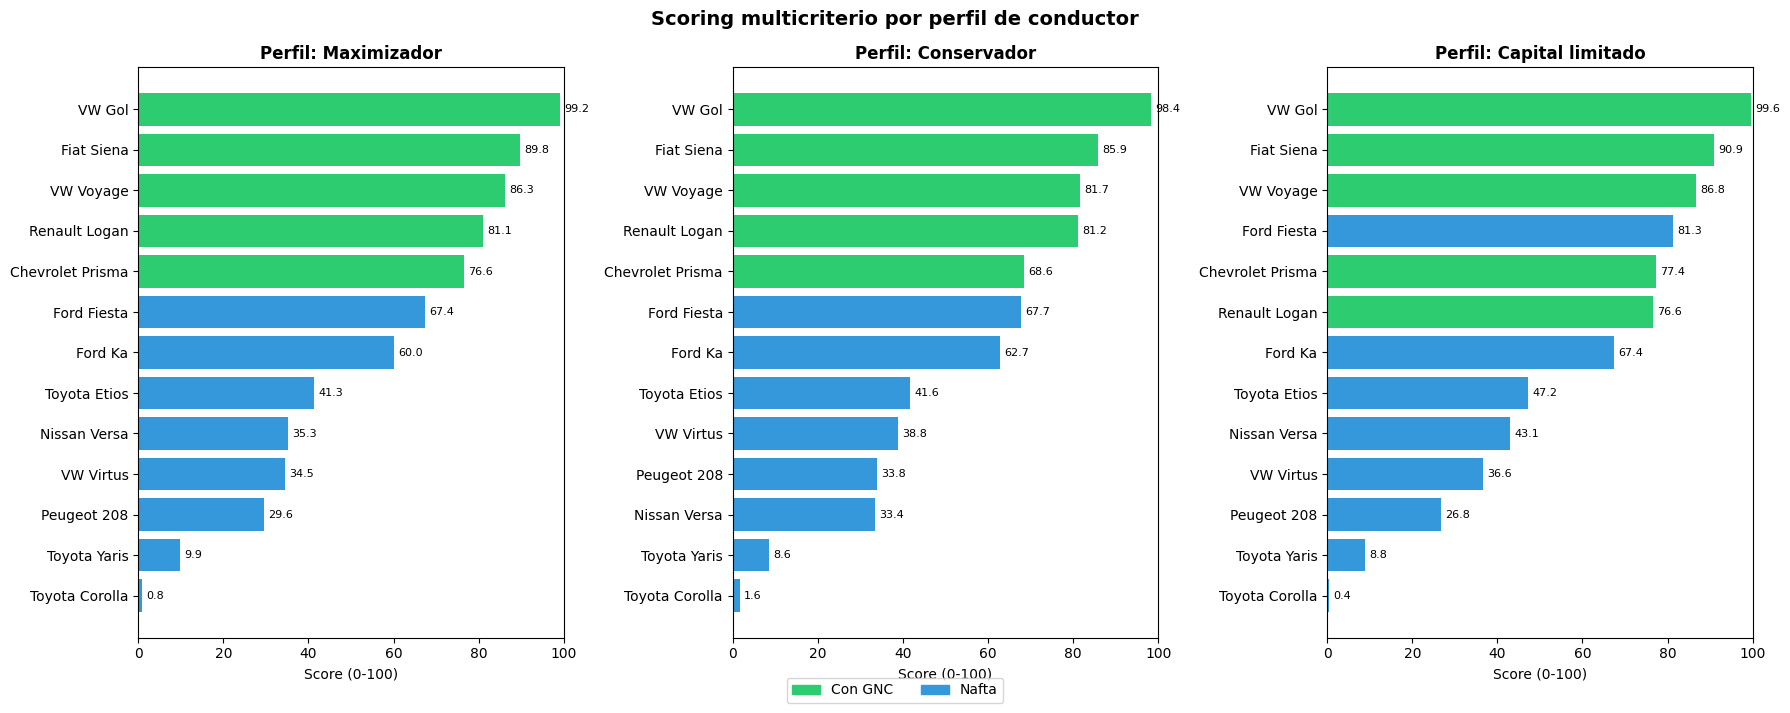

Gráfico guardado.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Scoring multicriterio por perfil de conductor", fontsize=14, fontweight="bold")

for ax, perfil in zip(axes, perfiles):
    col = f"score_{perfil}"
    df_plot = metricas[col].sort_values(ascending=True)
    colores = ["#2ecc71" if tiene_gnc[m] else "#3498db" for m in df_plot.index]

    ax.barh(df_plot.index, df_plot.values, color=colores)
    ax.set_title(f"Perfil: {perfil}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Score (0-100)")
    ax.set_xlim(0, 100)
    for i, v in enumerate(df_plot.values):
        ax.text(v + 1, i, f"{v:.1f}", va="center", fontsize=8)

patch_gnc   = mpatches.Patch(color="#2ecc71", label="Con GNC")
patch_nafta = mpatches.Patch(color="#3498db", label="Nafta")
fig.legend(handles=[patch_gnc, patch_nafta], loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("../reports/figures/05_scoring_perfiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado.")

### Interpretación del scoring multicriterio

Los tres perfiles confirman que el **VW Gol domina en cualquier contexto**,
obteniendo el primer puesto con scores superiores a 98/100 en los tres perfiles.
Sin embargo, hay matices importantes en los puestos siguientes:

**Perfil Maximizador:** el top 5 está compuesto íntegramente por autos con GNC.
La rentabilidad mensual es tan superior en estos modelos que ningún auto a nafta
puede competir con ellos cuando el objetivo es maximizar ganancias.

**Perfil Conservador:** el ranking casi no cambia respecto al Maximizador, pero
por una razón distinta. Los autos con GNC no solo ganan más — generan ganancias
más **predecibles y estables**. Su desvío estándar en la simulación de Montecarlo
es menor, lo que significa que tienen menos meses malos. Un conductor conservador
valora esa estabilidad tanto como la ganancia media.

**Perfil Capital limitado:** es el perfil donde el ranking cambia más. El
**Ford Fiesta sube al puesto 4**, desplazando al Renault Logan. Para un conductor
con presupuesto acotado, un auto barato a nafta puede competir con los GNC porque
el bajo precio de entrada genera un payback rápido y una amortización mensual baja.
Esto demuestra que **el GNC no es la única estrategia ganadora** — un auto muy
barato a nafta puede ser igualmente atractivo si el capital es la restricción principal.

**Conclusión general:** la decisión de qué auto comprar no tiene una respuesta
única — depende del perfil del conductor. Sin embargo, el VW Gol con GNC es
robusto ante cualquier perfil: es barato, tiene GNC y recupera la inversión
en menos de 7 meses.